In [30]:
import os, sys
sys.path.insert(0, r'C:\Users\sp6497_a\FTIR')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from FTIR_analysis_helpers import MultipassMeas

In [31]:
sample_name = 'P12-9-25-1MP'
numin, numax = 820, 3100

base_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\20260203_P12-9-25-1-MP\20260211'
bg_dir   = base_dir

In [32]:
samp_meas = MultipassMeas(
    TEfile    = os.path.join(base_dir, sample_name + '-P90deg.CSV'),
    TMfile    = os.path.join(base_dir, sample_name + '-P0deg.CSV'),
    name      = sample_name,
    nuextrema = [numin, numax],
)

bg_meas = MultipassMeas(
    TEfile    = os.path.join(bg_dir, 'P90deg_bg_realigned.CSV'),
    TMfile    = os.path.join(bg_dir, 'P0deg_bg_realigned.CSV'),
    name      = 'no-samp',
    nuextrema = [numin, numax],
)

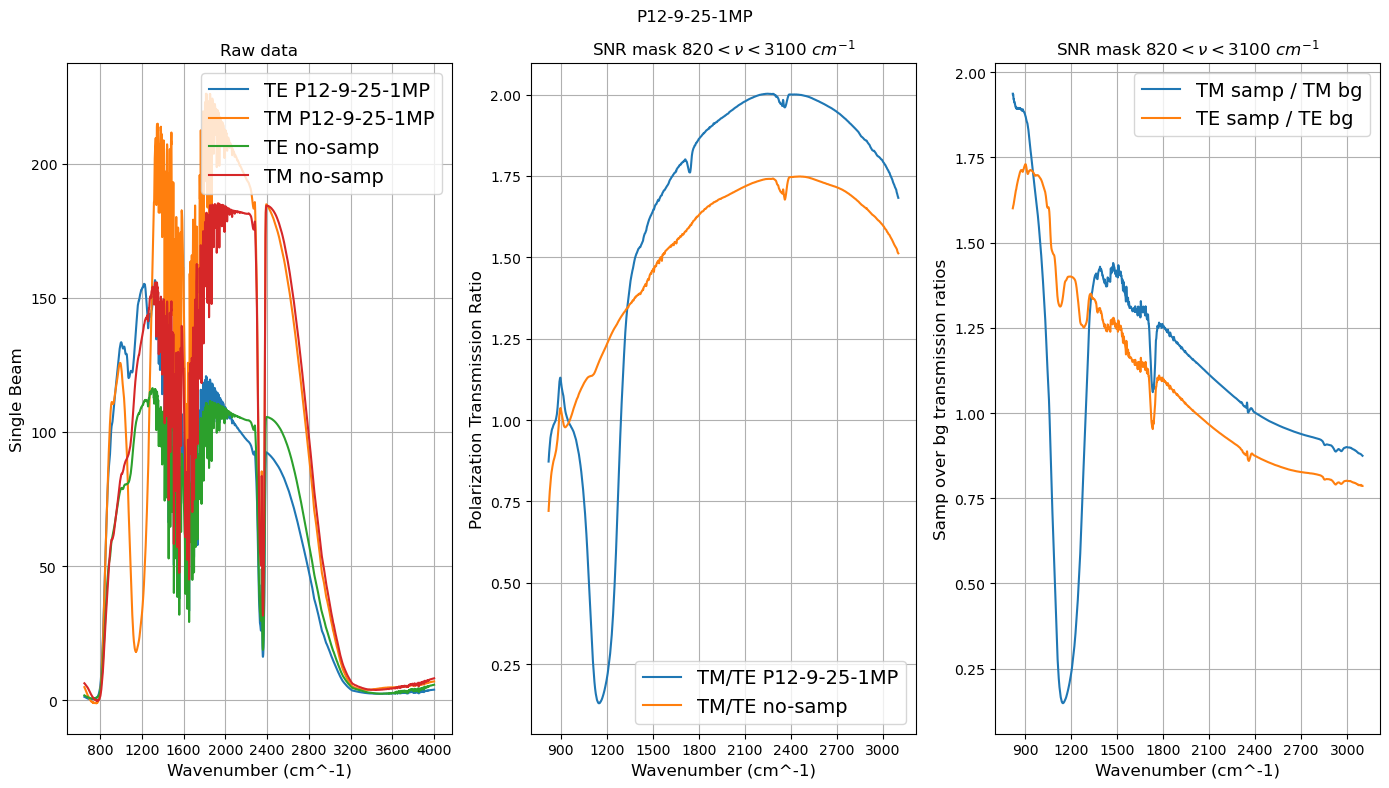

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(14, 8))
fig.suptitle(sample_name)

axs[0].set_title('Raw data')
axs[0].set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs[0].set_ylabel('Single Beam', fontsize=12)

snr_title = f'SNR mask {numin}' + r'$ < \nu < $' + f'{numax}' + r' ${cm}^{-1}$'
axs[1].set_title(snr_title)
axs[1].set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs[1].set_ylabel('Polarization Transmission Ratio', fontsize=12)

axs[2].set_title(snr_title)
axs[2].set_xlabel('Wavenumber (cm^-1)', fontsize=12)
axs[2].set_ylabel('Samp over bg transmission ratios', fontsize=12)

for ax in axs:
    ax.grid()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

samp_meas.plot_single_beam(axs[0])
bg_meas.plot_single_beam(axs[0])

samp_meas.plot_ratio(axs[1])
bg_meas.plot_ratio(axs[1])

axs[2].plot(samp_meas.TM_wavenum_masked, samp_meas.TM_masked / bg_meas.TM_masked, label='TM samp / TM bg')
axs[2].plot(samp_meas.TE_wavenum_masked, samp_meas.TE_masked / bg_meas.TE_masked, label='TE samp / TE bg')

for ax in axs:
    ax.legend(prop={'size': 14})
plt.tight_layout()
plt.savefig(os.path.join(base_dir, sample_name + '_raw_scans_and_ratios.svg'))

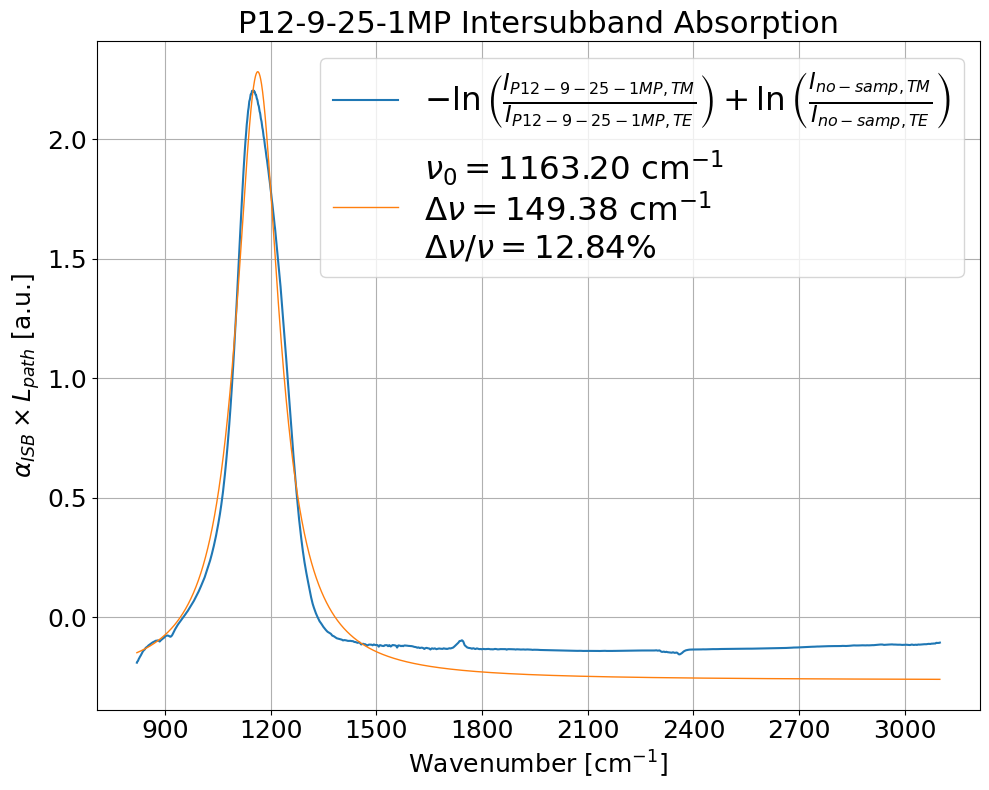

In [ ]:
fig_fits, axs_fits = plt.subplots(figsize=(12, 8))
base_title = sample_name + ' Intersubband Absorption'
base_font_size = 18
title_fontsize = 22
axs_fits.set_title(base_title, fontsize=title_fontsize)
axs_fits.set_xlabel(r'Wavenumber [$\text{cm}^{-1}$]', fontsize=base_font_size)
axs_fits.set_ylabel(r'$\alpha_{ISB} \times L_{path}$ [a.u.]', fontsize=base_font_size)
axs_fits.tick_params(axis='both', which='major', labelsize=base_font_size)
axs_fits.grid()
axs_fits.xaxis.set_major_locator(MaxNLocator(integer=True))
samp_meas.plot_alpha_ISB(bg_meas, axs_fits)

# Single Lorentzian fit
result = samp_meas.fit_lorentz(
    nu_range    = [1060, 1670],
    nu0_guess   = 1100,
    kappa_guess = 65,
    background  = bg_meas,
)
samp_meas.plot_fit(result, axs_fits)

axs_fits.legend(prop={'size': base_font_size*1.3})
# axs_fits.
plt.tight_layout()
# plt.savefig(os.path.join(base_dir, sample_name + '_alpha_ISB.svg'))
# plt.show()